##Homework 3:

Imports:

In [1]:
import re
import random
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download("punkt")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Using cuda


File Upload:

In [2]:
from google.colab import files

uploaded = files.upload()

DATA_PATH = "vast_english_french.txt"

Saving vast_english_french.txt to vast_english_french.txt


##Problem 1:

In [3]:
def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r"([.!?])", r" \1", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ.!?]+", r" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

pairs = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            eng = normalize_text(parts[0])
            fra = normalize_text(parts[1])
            pairs.append((eng, fra))

print("Total sentence pairs:", len(pairs))
print(pairs[:5])

random.shuffle(pairs)

split_idx = int(0.8 * len(pairs))

train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))

Total sentence pairs: 555
[('i am cold', 'j ai froid'), ('you are tired', 'tu es fatigué'), ('he is hungry', 'il a faim'), ('she is happy', 'elle est heureuse'), ('we are friends', 'nous sommes amis')]
Training pairs: 444
Validation pairs: 111


Vocabulary:

In [4]:
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3


class Vocabulary:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.word2idx = {
            PAD_TOKEN: PAD_IDX,
            SOS_TOKEN: SOS_IDX,
            EOS_TOKEN: EOS_IDX,
            UNK_TOKEN: UNK_IDX
        }
        self.idx2word = {
            PAD_IDX: PAD_TOKEN,
            SOS_IDX: SOS_TOKEN,
            EOS_IDX: EOS_TOKEN,
            UNK_IDX: UNK_TOKEN
        }

    def build_vocab(self, sentences):
        counter = Counter()

        for sentence in sentences:
            counter.update(sentence.split())

        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def numericalize(self, sentence):
        return [
            self.word2idx.get(word, UNK_IDX)
            for word in sentence.split()
        ]

    def __len__(self):
        return len(self.word2idx)

src_vocab = Vocabulary(min_freq=1)
trg_vocab = Vocabulary(min_freq=1)

src_vocab.build_vocab([pair[0] for pair in train_pairs])
trg_vocab.build_vocab([pair[1] for pair in train_pairs])

print("English vocab size:", len(src_vocab))
print("French vocab size:", len(trg_vocab))

English vocab size: 894
French vocab size: 984


Dataset and Loaderr:

In [5]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_text, trg_text = self.pairs[idx]

        src_indices = [SOS_IDX] + self.src_vocab.numericalize(src_text) + [EOS_IDX]
        trg_indices = [SOS_IDX] + self.trg_vocab.numericalize(trg_text) + [EOS_IDX]

        return torch.tensor(src_indices), torch.tensor(trg_indices), src_text, trg_text


def collate_fn(batch):
    src_batch, trg_batch, src_texts, trg_texts = zip(*batch)

    src_batch = nn.utils.rnn.pad_sequence(
        src_batch, padding_value=PAD_IDX, batch_first=True
    )

    trg_batch = nn.utils.rnn.pad_sequence(
        trg_batch, padding_value=PAD_IDX, batch_first=True
    )

    return src_batch, trg_batch, src_texts, trg_texts


BATCH_SIZE = 64

train_dataset = TranslationDataset(train_pairs, src_vocab, trg_vocab)
val_dataset = TranslationDataset(val_pairs, src_vocab, trg_vocab)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

GRU Model:

In [6]:
class EncoderGRU(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.gru(embedded)
        return hidden


class DecoderGRU(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.output_dim = output_dim

        self.embedding = nn.Embedding(output_dim, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_token, hidden):
        input_token = input_token.unsqueeze(1)
        embedded = self.embedding(input_token)

        output, hidden = self.gru(embedded, hidden)

        prediction = self.fc_out(output.squeeze(1))

        return prediction, hidden


class Seq2SeqGRU(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        hidden = self.encoder(src)

        input_token = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden = self.decoder(input_token, hidden)

            outputs[:, t, :] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            input_token = trg[:, t] if teacher_force else top1

        return outputs

##Intialization

INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(trg_vocab)

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 1
DROPOUT = 0.2

encoder = EncoderGRU(
    INPUT_DIM,
    ENC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT
)

decoder = DecoderGRU(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT
)

model = Seq2SeqGRU(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print(model)

Seq2SeqGRU(
  (encoder): EncoderGRU(
    (embedding): Embedding(894, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True)
  )
  (decoder): DecoderGRU(
    (embedding): Embedding(984, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=984, bias=True)
  )
)


Training:

In [7]:
def train_one_epoch(model, dataloader, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0

    for src, trg, _, _ in dataloader:
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(src, trg, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]

        output = output[:, 1:, :].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)


def evaluate_loss(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg, _, _ in dataloader:
            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]

            output = output[:, 1:, :].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

N_EPOCHS = 15

train_losses = []
val_losses = []

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate_loss(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    end_time = time.time()

    print(
        f"Epoch {epoch+1:02}/{N_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Time: {end_time - start_time:.2f}s"
    )

Epoch 01/15 | Train Loss: 6.4829 | Val Loss: 5.5773 | Time: 0.94s
Epoch 02/15 | Train Loss: 5.3500 | Val Loss: 5.5128 | Time: 0.16s
Epoch 03/15 | Train Loss: 5.0201 | Val Loss: 5.4908 | Time: 0.17s
Epoch 04/15 | Train Loss: 4.8199 | Val Loss: 5.4301 | Time: 0.17s
Epoch 05/15 | Train Loss: 4.5757 | Val Loss: 5.3612 | Time: 0.17s
Epoch 06/15 | Train Loss: 4.3531 | Val Loss: 5.2502 | Time: 0.18s
Epoch 07/15 | Train Loss: 4.1237 | Val Loss: 5.2311 | Time: 0.18s
Epoch 08/15 | Train Loss: 4.0125 | Val Loss: 5.1914 | Time: 0.17s
Epoch 09/15 | Train Loss: 3.6839 | Val Loss: 5.1442 | Time: 0.16s
Epoch 10/15 | Train Loss: 3.4584 | Val Loss: 5.1330 | Time: 0.16s
Epoch 11/15 | Train Loss: 3.2619 | Val Loss: 5.2124 | Time: 0.16s
Epoch 12/15 | Train Loss: 3.2194 | Val Loss: 5.1779 | Time: 0.17s
Epoch 13/15 | Train Loss: 3.0546 | Val Loss: 5.1738 | Time: 0.17s
Epoch 14/15 | Train Loss: 2.7533 | Val Loss: 5.1261 | Time: 0.17s
Epoch 15/15 | Train Loss: 2.6645 | Val Loss: 5.1592 | Time: 0.16s


Plots:

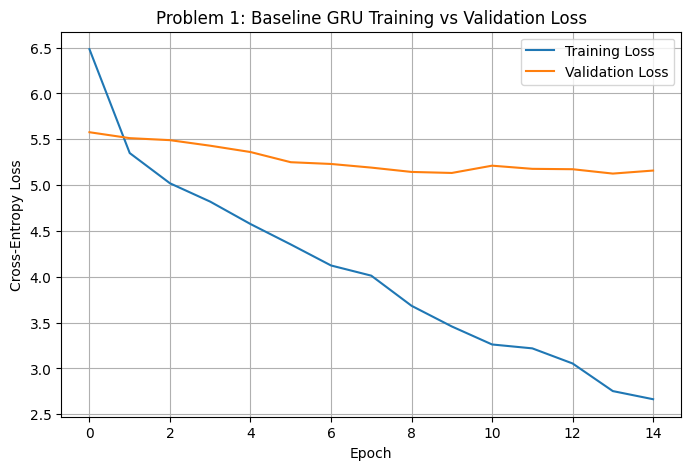

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 1: Baseline GRU Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Plot Training:

In [9]:
def translate_sentence(model, sentence, src_vocab, trg_vocab, max_len=50):
    model.eval()

    sentence = normalize_text(sentence)

    src_indices = [SOS_IDX] + src_vocab.numericalize(sentence) + [EOS_IDX]
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden = model.encoder(src_tensor)

    input_token = torch.tensor([SOS_IDX]).to(device)

    generated_tokens = []

    with torch.no_grad():
        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)

            top1 = output.argmax(1).item()

            if top1 == EOS_IDX:
                break

            generated_tokens.append(top1)

            input_token = torch.tensor([top1]).to(device)

    generated_words = [
        trg_vocab.idx2word.get(idx, UNK_TOKEN)
        for idx in generated_tokens
    ]

    return " ".join(generated_words)


def evaluate_translation_metrics(model, pairs, src_vocab, trg_vocab, max_samples=None):
    smoothie = SmoothingFunction().method1

    exact_matches = 0
    bleu_scores = []

    if max_samples is not None:
        pairs = pairs[:max_samples]

    for src_text, target_text in pairs:
        predicted_text = translate_sentence(
            model,
            src_text,
            src_vocab,
            trg_vocab
        )

        exact_match = predicted_text.strip() == target_text.strip()

        if exact_match:
            exact_matches += 1

        reference = [target_text.split()]
        candidate = predicted_text.split()

        bleu = sentence_bleu(
            reference,
            candidate,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smoothie
        )

        bleu_scores.append(bleu)

    exact_accuracy = exact_matches / len(pairs)
    average_bleu = sum(bleu_scores) / len(bleu_scores)

    return exact_accuracy, average_bleu


exact_acc, bleu4 = evaluate_translation_metrics(
    model,
    val_pairs,
    src_vocab,
    trg_vocab
)

print(f"Validation Exact Match Accuracy: {exact_acc * 100:.2f}%")
print(f"Validation BLEU-4 Score: {bleu4:.4f}")

Validation Exact Match Accuracy: 0.00%
Validation BLEU-4 Score: 0.0615


Examples:

In [10]:
sample_examples = random.sample(val_pairs, 5)

smoothie = SmoothingFunction().method1

for i, (src_text, target_text) in enumerate(sample_examples, 1):
    predicted_text = translate_sentence(
        model,
        src_text,
        src_vocab,
        trg_vocab
    )

    exact_match = predicted_text.strip() == target_text.strip()

    bleu = sentence_bleu(
        [target_text.split()],
        predicted_text.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    print(f"Example {i}")
    print("English Input:      ", src_text)
    print("Target French:      ", target_text)
    print("Predicted French:   ", predicted_text)
    print("Exact Match:        ", exact_match)
    print(f"BLEU-4 Score:       {bleu:.4f}")
    print("-" * 70)

Example 1
English Input:       he vacuums his entire house every friday afternoon
Target French:       il passe l aspirateur dans toute sa maison tous les vendredis après midi
Predicted French:    il a terminé son portefeuille à l hôpital
Exact Match:         False
BLEU-4 Score:       0.0177
----------------------------------------------------------------------
Example 2
English Input:       they speak french at home
Target French:       ils parlent français à la maison
Predicted French:    ils parlent souvent un accent de
Exact Match:         False
BLEU-4 Score:       0.0863
----------------------------------------------------------------------
Example 3
English Input:       the weather is perfect today
Target French:       le temps est parfait aujourd hui
Predicted French:    le koala grimpe sur le parc
Exact Match:         False
BLEU-4 Score:       0.0408
----------------------------------------------------------------------
Example 4
English Input:       they spent their vacation e

##Problem 2:

Attention & Bahdanau Encoder:

In [11]:
class AttentionEncoderGRU(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

    def forward(self, src):
        embedded = self.embedding(src)

        encoder_outputs, hidden = self.gru(embedded)

        return encoder_outputs, hidden

##Bahdanau Attention:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask):
        # decoder_hidden: [batch, hidden_dim]
        # encoder_outputs: [batch, src_len, hidden_dim]

        src_len = encoder_outputs.shape[1]

        decoder_hidden = decoder_hidden.unsqueeze(1).repeat(1, src_len, 1)

        energy = torch.tanh(
            self.attn(torch.cat((decoder_hidden, encoder_outputs), dim=2))
        )

        attention = self.v(energy).squeeze(2)

        attention = attention.masked_fill(mask == 0, -1e10)

        return torch.softmax(attention, dim=1)

In [12]:
class AttentionDecoderGRU(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, num_layers, dropout, attention):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, embed_dim, padding_idx=PAD_IDX)

        self.gru = nn.GRU(
            embed_dim + hidden_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.fc_out = nn.Linear(embed_dim + hidden_dim * 2, output_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs, mask):
        input_token = input_token.unsqueeze(1)

        embedded = self.dropout(self.embedding(input_token))

        decoder_hidden = hidden[-1]

        attn_weights = self.attention(decoder_hidden, encoder_outputs, mask)

        attn_weights_unsqueezed = attn_weights.unsqueeze(1)

        context = torch.bmm(attn_weights_unsqueezed, encoder_outputs)

        gru_input = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(gru_input, hidden)

        prediction = self.fc_out(
            torch.cat(
                (
                    output.squeeze(1),
                    context.squeeze(1),
                    embedded.squeeze(1)
                ),
                dim=1
            )
        )

        return prediction, hidden, attn_weights

class Seq2SeqAttentionGRU(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def create_mask(self, src):
        return (src != PAD_IDX).to(self.device)

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src)

        mask = self.create_mask(src)

        input_token = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden, _ = self.decoder(
                input_token,
                hidden,
                encoder_outputs,
                mask
            )

            outputs[:, t, :] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            input_token = trg[:, t] if teacher_force else top1

        return outputs

Initialization & Training:

In [13]:
INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(trg_vocab)

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 1
DROPOUT = 0.2

attention = BahdanauAttention(HIDDEN_DIM)

attention_encoder = AttentionEncoderGRU(
    INPUT_DIM,
    ENC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT
)

attention_decoder = AttentionDecoderGRU(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT,
    attention
)

attention_model = Seq2SeqAttentionGRU(
    attention_encoder,
    attention_decoder,
    device
).to(device)

attention_optimizer = optim.Adam(attention_model.parameters(), lr=0.001)

print(attention_model)


##Training:
N_EPOCHS = 15

attention_train_losses = []
attention_val_losses = []

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_one_epoch(
        attention_model,
        train_loader,
        attention_optimizer,
        criterion
    )

    val_loss = evaluate_loss(
        attention_model,
        val_loader,
        criterion
    )

    attention_train_losses.append(train_loss)
    attention_val_losses.append(val_loss)

    end_time = time.time()

    print(
        f"Epoch {epoch+1:02}/{N_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Time: {end_time - start_time:.2f}s"
    )

Seq2SeqAttentionGRU(
  (encoder): AttentionEncoderGRU(
    (embedding): Embedding(894, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True)
  )
  (decoder): AttentionDecoderGRU(
    (attention): BahdanauAttention(
      (attn): Linear(in_features=1024, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(984, 256, padding_idx=0)
    (gru): GRU(768, 512, batch_first=True)
    (fc_out): Linear(in_features=1280, out_features=984, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)
Epoch 01/15 | Train Loss: 6.2519 | Val Loss: 5.7236 | Time: 0.43s
Epoch 02/15 | Train Loss: 5.0427 | Val Loss: 5.3960 | Time: 0.30s
Epoch 03/15 | Train Loss: 4.4798 | Val Loss: 5.1762 | Time: 0.31s
Epoch 04/15 | Train Loss: 3.9371 | Val Loss: 5.0328 | Time: 0.31s
Epoch 05/15 | Train Loss: 3.3403 | Val Loss: 5.0224 | Time: 0.30s
Epoch 06/15 | Train Loss: 2.9128 | Val Loss: 5.0534 | Time: 0.31s
Epoch 07/15 | Train Loss: 2.4

Plots:

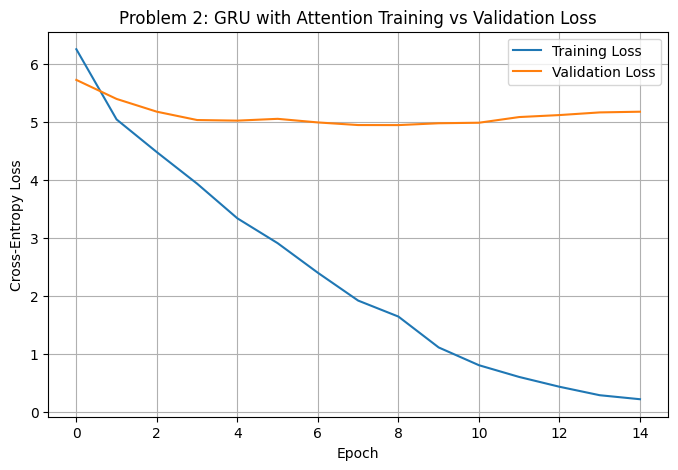

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(attention_train_losses, label="Training Loss")
plt.plot(attention_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 2: GRU with Attention Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

Validation Scores:

In [15]:
def translate_sentence_attention(model, sentence, src_vocab, trg_vocab, max_len=50):
    model.eval()

    sentence = normalize_text(sentence)

    src_indices = [SOS_IDX] + src_vocab.numericalize(sentence) + [EOS_IDX]
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)

    src_tokens = [SOS_TOKEN] + sentence.split() + [EOS_TOKEN]

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    mask = model.create_mask(src_tensor)

    input_token = torch.tensor([SOS_IDX]).to(device)

    generated_tokens = []
    attention_weights = []

    with torch.no_grad():
        for _ in range(max_len):
            output, hidden, attn = model.decoder(
                input_token,
                hidden,
                encoder_outputs,
                mask
            )

            top1 = output.argmax(1).item()

            if top1 == EOS_IDX:
                break

            generated_tokens.append(top1)
            attention_weights.append(attn.squeeze(0).cpu().numpy())

            input_token = torch.tensor([top1]).to(device)

    generated_words = [
        trg_vocab.idx2word.get(idx, UNK_TOKEN)
        for idx in generated_tokens
    ]

    return " ".join(generated_words), generated_words, src_tokens, attention_weights


def evaluate_attention_metrics(model, pairs, src_vocab, trg_vocab, max_samples=None):
    smoothie = SmoothingFunction().method1

    exact_matches = 0
    bleu_scores = []

    if max_samples is not None:
        pairs = pairs[:max_samples]

    for src_text, target_text in pairs:
        predicted_text, _, _, _ = translate_sentence_attention(
            model,
            src_text,
            src_vocab,
            trg_vocab
        )

        exact_match = predicted_text.strip() == target_text.strip()

        if exact_match:
            exact_matches += 1

        reference = [target_text.split()]
        candidate = predicted_text.split()

        bleu = sentence_bleu(
            reference,
            candidate,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smoothie
        )

        bleu_scores.append(bleu)

    exact_accuracy = exact_matches / len(pairs)
    average_bleu = sum(bleu_scores) / len(bleu_scores)

    return exact_accuracy, average_bleu


attention_exact_acc, attention_bleu4 = evaluate_attention_metrics(
    attention_model,
    val_pairs,
    src_vocab,
    trg_vocab
)

print(f"Attention Validation Exact Match Accuracy: {attention_exact_acc * 100:.2f}%")
print(f"Attention Validation BLEU-4 Score: {attention_bleu4:.4f}")

Attention Validation Exact Match Accuracy: 0.90%
Attention Validation BLEU-4 Score: 0.1340


Examples:

In [16]:
sample_examples = random.sample(val_pairs, 5)

smoothie = SmoothingFunction().method1

for i, (src_text, target_text) in enumerate(sample_examples, 1):
    predicted_text, _, _, _ = translate_sentence_attention(
        attention_model,
        src_text,
        src_vocab,
        trg_vocab
    )

    exact_match = predicted_text.strip() == target_text.strip()

    bleu = sentence_bleu(
        [target_text.split()],
        predicted_text.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    print(f"Example {i}")
    print("English Input:      ", src_text)
    print("Target French:      ", target_text)
    print("Predicted French:   ", predicted_text)
    print("Exact Match:        ", exact_match)
    print(f"BLEU-4 Score:       {bleu:.4f}")
    print("-" * 70)

Example 1
English Input:       he finished his test early
Target French:       il a fini son test en avance
Predicted French:    il a terminé son projet d entraînement plus
Exact Match:         False
BLEU-4 Score:       0.0650
----------------------------------------------------------------------
Example 2
English Input:       the flowers bloom in spring
Target French:       les fleurs fleurissent au printemps
Predicted French:    le magasin ouvre dans le parc
Exact Match:         False
BLEU-4 Score:       0.0000
----------------------------------------------------------------------
Example 3
English Input:       they swim in the pool
Target French:       ils nagent dans la piscine
Predicted French:    ils nourrissent dans la randonnée dans la forêt
Exact Match:         False
BLEU-4 Score:       0.0650
----------------------------------------------------------------------
Example 4
English Input:       they feed the pigeons in the square
Target French:       ils nourrissent les pigeons

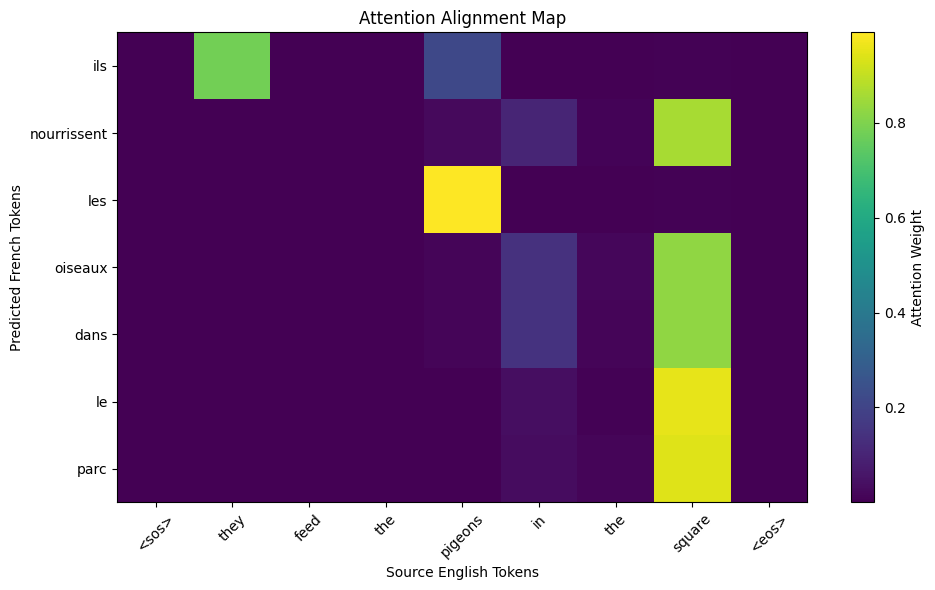

Source English:      they feed the pigeons in the square
Target French:       ils nourrissent les pigeons sur la place
Predicted French:    ils nourrissent les oiseaux dans le parc


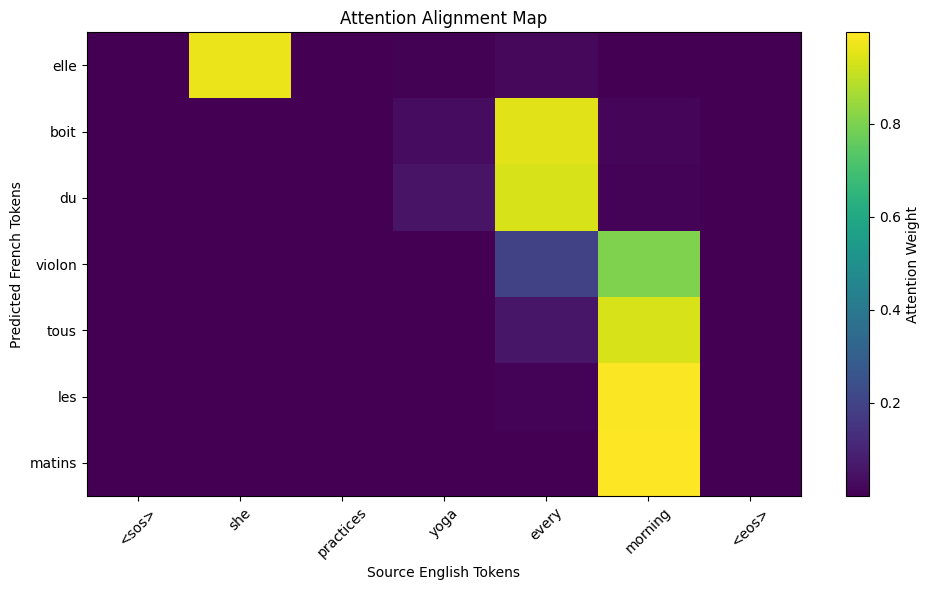

Source English:      she practices yoga every morning
Target French:       elle pratique le yoga tous les matins
Predicted French:    elle boit du violon tous les matins


In [17]:
def plot_attention_map(model, src_sentence, target_sentence=None):
    predicted_text, pred_tokens, src_tokens, attention_weights = translate_sentence_attention(
        model,
        src_sentence,
        src_vocab,
        trg_vocab
    )

    if len(attention_weights) == 0:
        print("No attention weights to plot.")
        return

    attention_matrix = np.array(attention_weights)

    plt.figure(figsize=(10, 6))
    plt.imshow(attention_matrix, aspect="auto")

    plt.xticks(range(len(src_tokens)), src_tokens, rotation=45)
    plt.yticks(range(len(pred_tokens)), pred_tokens)

    plt.xlabel("Source English Tokens")
    plt.ylabel("Predicted French Tokens")
    plt.title("Attention Alignment Map")
    plt.colorbar(label="Attention Weight")
    plt.tight_layout()
    plt.show()

    print("Source English:     ", src_sentence)

    if target_sentence is not None:
        print("Target French:      ", target_sentence)

    print("Predicted French:   ", predicted_text)

##Sample Sentences:
example_1 = val_pairs[0]
example_2 = val_pairs[1]

plot_attention_map(attention_model, example_1[0], example_1[1])
plot_attention_map(attention_model, example_2[0], example_2[1])

##Problem 3:

Reversing Data Split and Building New Vocabularies:

In [18]:

train_pairs_rev = [(fra, eng) for eng, fra in train_pairs]
val_pairs_rev = [(fra, eng) for eng, fra in val_pairs]

print("Example reversed pair:")
print("French source:", train_pairs_rev[0][0])
print("English target:", train_pairs_rev[0][1])

src_vocab_rev = Vocabulary(min_freq=1)  # French vocabulary
trg_vocab_rev = Vocabulary(min_freq=1)  # English vocabulary

src_vocab_rev.build_vocab([pair[0] for pair in train_pairs_rev])
trg_vocab_rev.build_vocab([pair[1] for pair in train_pairs_rev])

print("French source vocab size:", len(src_vocab_rev))
print("English target vocab size:", len(trg_vocab_rev))

Example reversed pair:
French source: il enseigne la géographie mondiale à des classes de lycée
English target: he teaches world geography to high school classes
French source vocab size: 984
English target vocab size: 894


In [19]:
train_dataset_rev = TranslationDataset(
    train_pairs_rev,
    src_vocab_rev,
    trg_vocab_rev
)

val_dataset_rev = TranslationDataset(
    val_pairs_rev,
    src_vocab_rev,
    trg_vocab_rev
)

train_loader_rev = DataLoader(
    train_dataset_rev,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader_rev = DataLoader(
    val_dataset_rev,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

Baselin GRU Model:

Seq2SeqGRU(
  (encoder): EncoderGRU(
    (embedding): Embedding(984, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True)
  )
  (decoder): DecoderGRU(
    (embedding): Embedding(894, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=894, bias=True)
  )
)
Epoch 01/15 | Train Loss: 6.2294 | Val Loss: 5.8363 | Time: 0.14s
Epoch 02/15 | Train Loss: 5.1313 | Val Loss: 5.3503 | Time: 0.14s
Epoch 03/15 | Train Loss: 4.8616 | Val Loss: 5.2177 | Time: 0.14s
Epoch 04/15 | Train Loss: 4.6587 | Val Loss: 5.2435 | Time: 0.14s
Epoch 05/15 | Train Loss: 4.4365 | Val Loss: 5.1772 | Time: 0.14s
Epoch 06/15 | Train Loss: 4.2296 | Val Loss: 5.0414 | Time: 0.14s
Epoch 07/15 | Train Loss: 3.9717 | Val Loss: 5.0037 | Time: 0.14s
Epoch 08/15 | Train Loss: 3.7631 | Val Loss: 4.9667 | Time: 0.14s
Epoch 09/15 | Train Loss: 3.5103 | Val Loss: 4.9379 | Time: 0.15s
Epoch 10/15 | Train Loss: 3.4058 | Val Loss: 4.9637 | Time: 0.14s
Epoch 11/15

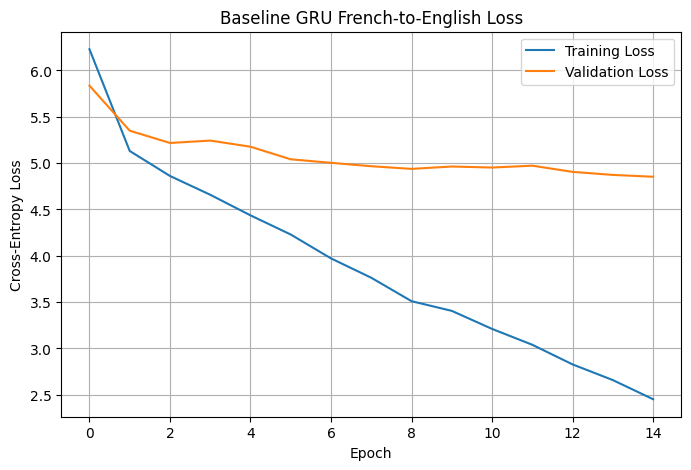

French-to-English Baseline Exact Match Accuracy: 0.00%
French-to-English Baseline BLEU-4 Score: 0.0817


In [20]:
INPUT_DIM_REV = len(src_vocab_rev)
OUTPUT_DIM_REV = len(trg_vocab_rev)

baseline_encoder_rev = EncoderGRU(
    INPUT_DIM_REV,
    ENC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT
)

baseline_decoder_rev = DecoderGRU(
    OUTPUT_DIM_REV,
    DEC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT
)

baseline_model_rev = Seq2SeqGRU(
    baseline_encoder_rev,
    baseline_decoder_rev,
    device
).to(device)

baseline_optimizer_rev = optim.Adam(
    baseline_model_rev.parameters(),
    lr=0.001
)

print(baseline_model_rev)


N_EPOCHS = 15

baseline_rev_train_losses = []
baseline_rev_val_losses = []

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_one_epoch(
        baseline_model_rev,
        train_loader_rev,
        baseline_optimizer_rev,
        criterion
    )

    val_loss = evaluate_loss(
        baseline_model_rev,
        val_loader_rev,
        criterion
    )

    baseline_rev_train_losses.append(train_loss)
    baseline_rev_val_losses.append(val_loss)

    end_time = time.time()

    print(
        f"Epoch {epoch+1:02}/{N_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Time: {end_time - start_time:.2f}s"
    )


#Plots
plt.figure(figsize=(8, 5))
plt.plot(baseline_rev_train_losses, label="Training Loss")
plt.plot(baseline_rev_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Baseline GRU French-to-English Loss")
plt.legend()
plt.grid(True)
plt.show()

baseline_rev_exact_acc, baseline_rev_bleu4 = evaluate_translation_metrics(
    baseline_model_rev,
    val_pairs_rev,
    src_vocab_rev,
    trg_vocab_rev
)

print(f"French-to-English Baseline Exact Match Accuracy: {baseline_rev_exact_acc * 100:.2f}%")
print(f"French-to-English Baseline BLEU-4 Score: {baseline_rev_bleu4:.4f}")


Attention GRU Model:

Seq2SeqAttentionGRU(
  (encoder): AttentionEncoderGRU(
    (embedding): Embedding(984, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True)
  )
  (decoder): AttentionDecoderGRU(
    (attention): BahdanauAttention(
      (attn): Linear(in_features=1024, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(894, 256, padding_idx=0)
    (gru): GRU(768, 512, batch_first=True)
    (fc_out): Linear(in_features=1280, out_features=894, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)
Epoch 01/15 | Train Loss: 6.0512 | Val Loss: 5.5274 | Time: 0.24s
Epoch 02/15 | Train Loss: 4.8970 | Val Loss: 5.1561 | Time: 0.24s
Epoch 03/15 | Train Loss: 4.2931 | Val Loss: 5.0023 | Time: 0.24s
Epoch 04/15 | Train Loss: 3.6741 | Val Loss: 4.8318 | Time: 0.24s
Epoch 05/15 | Train Loss: 3.2420 | Val Loss: 4.8233 | Time: 0.24s
Epoch 06/15 | Train Loss: 2.7449 | Val Loss: 4.8294 | Time: 0.24s
Epoch 07/15 | Train Loss: 2.2

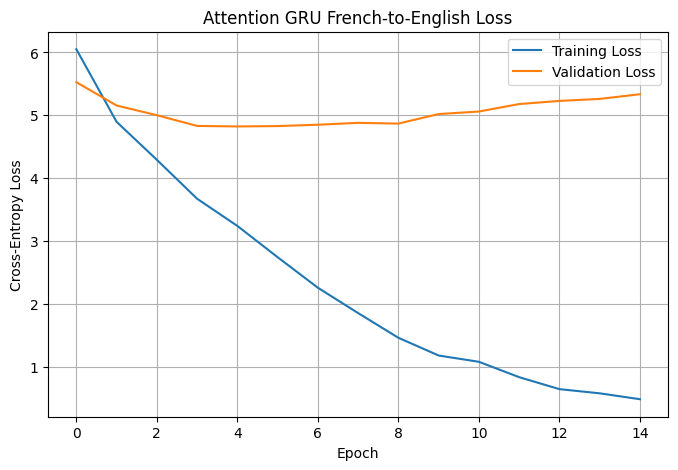

French-to-English Attention Exact Match Accuracy: 0.00%
French-to-English Attention BLEU-4 Score: 0.1284


In [23]:
attention_rev = BahdanauAttention(HIDDEN_DIM)

attention_encoder_rev = AttentionEncoderGRU(
    INPUT_DIM_REV,
    ENC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT
)

attention_decoder_rev = AttentionDecoderGRU(
    OUTPUT_DIM_REV,
    DEC_EMB_DIM,
    HIDDEN_DIM,
    NUM_LAYERS,
    DROPOUT,
    attention_rev
)

attention_model_rev = Seq2SeqAttentionGRU(
    attention_encoder_rev,
    attention_decoder_rev,
    device
).to(device)

attention_optimizer_rev = optim.Adam(
    attention_model_rev.parameters(),
    lr=0.001
)

print(attention_model_rev)

attention_rev_train_losses = []
attention_rev_val_losses = []

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_one_epoch(
        attention_model_rev,
        train_loader_rev,
        attention_optimizer_rev,
        criterion
    )

    val_loss = evaluate_loss(
        attention_model_rev,
        val_loader_rev,
        criterion
    )

    attention_rev_train_losses.append(train_loss)
    attention_rev_val_losses.append(val_loss)

    end_time = time.time()

    print(
        f"Epoch {epoch+1:02}/{N_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Time: {end_time - start_time:.2f}s"
    )

#Plots
plt.figure(figsize=(8, 5))
plt.plot(attention_rev_train_losses, label="Training Loss")
plt.plot(attention_rev_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Attention GRU French-to-English Loss")
plt.legend()
plt.grid(True)
plt.show()

def translate_sentence_attention_rev(model, sentence, src_vocab, trg_vocab, max_len=50):
    model.eval()

    sentence = normalize_text(sentence)

    src_indices = [SOS_IDX] + src_vocab.numericalize(sentence) + [EOS_IDX]
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device)

    src_tokens = [SOS_TOKEN] + sentence.split() + [EOS_TOKEN]

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    mask = model.create_mask(src_tensor)

    input_token = torch.tensor([SOS_IDX]).to(device)

    generated_tokens = []
    attention_weights = []

    with torch.no_grad():
        for _ in range(max_len):
            output, hidden, attn = model.decoder(
                input_token,
                hidden,
                encoder_outputs,
                mask
            )

            top1 = output.argmax(1).item()

            if top1 == EOS_IDX:
                break

            generated_tokens.append(top1)
            attention_weights.append(attn.squeeze(0).cpu().numpy())

            input_token = torch.tensor([top1]).to(device)

    generated_words = [
        trg_vocab.idx2word.get(idx, UNK_TOKEN)
        for idx in generated_tokens
    ]

    return " ".join(generated_words), generated_words, src_tokens, attention_weights


def evaluate_attention_metrics_rev(model, pairs, src_vocab, trg_vocab, max_samples=None):
    smoothie = SmoothingFunction().method1

    exact_matches = 0
    bleu_scores = []

    if max_samples is not None:
        pairs = pairs[:max_samples]

    for src_text, target_text in pairs:
        predicted_text, _, _, _ = translate_sentence_attention_rev(
            model,
            src_text,
            src_vocab,
            trg_vocab
        )

        exact_match = predicted_text.strip() == target_text.strip()

        if exact_match:
            exact_matches += 1

        bleu = sentence_bleu(
            [target_text.split()],
            predicted_text.split(),
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smoothie
        )

        bleu_scores.append(bleu)

    exact_accuracy = exact_matches / len(pairs)
    average_bleu = sum(bleu_scores) / len(bleu_scores)

    return exact_accuracy, average_bleu


attention_rev_exact_acc, attention_rev_bleu4 = evaluate_attention_metrics_rev(
    attention_model_rev,
    val_pairs_rev,
    src_vocab_rev,
    trg_vocab_rev
)

print(f"French-to-English Attention Exact Match Accuracy: {attention_rev_exact_acc * 100:.2f}%")
print(f"French-to-English Attention BLEU-4 Score: {attention_rev_bleu4:.4f}")

Both Model Examples:

In [22]:
sample_examples_rev = random.sample(val_pairs_rev, 5)

smoothie = SmoothingFunction().method1

for i, (src_text, target_text) in enumerate(sample_examples_rev, 1):
    baseline_pred = translate_sentence(
        baseline_model_rev,
        src_text,
        src_vocab_rev,
        trg_vocab_rev
    )

    attention_pred, _, _, _ = translate_sentence_attention_rev(
        attention_model_rev,
        src_text,
        src_vocab_rev,
        trg_vocab_rev
    )

    baseline_exact = baseline_pred.strip() == target_text.strip()
    attention_exact = attention_pred.strip() == target_text.strip()

    baseline_bleu = sentence_bleu(
        [target_text.split()],
        baseline_pred.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    attention_bleu = sentence_bleu(
        [target_text.split()],
        attention_pred.split(),
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    print(f"Example {i}")
    print("French Input:              ", src_text)
    print("Target English:            ", target_text)
    print()
    print("Baseline Prediction:       ", baseline_pred)
    print("Baseline Exact Match:      ", baseline_exact)
    print(f"Baseline BLEU-4:           {baseline_bleu:.4f}")
    print()
    print("Attention Prediction:      ", attention_pred)
    print("Attention Exact Match:     ", attention_exact)
    print(f"Attention BLEU-4:          {attention_bleu:.4f}")
    print("-" * 80)

Example 1
French Input:               les clés manquent dans la poche de mon manteau
Target English:             the keys are missing from my coat pocket

Baseline Prediction:        the keys are in a beautiful to the
Baseline Exact Match:       False
Baseline BLEU-4:           0.1375

Attention Prediction:       the keys are in the trees
Attention Exact Match:      False
Attention BLEU-4:          0.1448
--------------------------------------------------------------------------------
Example 2
French Input:               il peint des paysages
Target English:             he paints landscapes

Baseline Prediction:        he finished his workout session earlier than
Baseline Exact Match:       False
Baseline BLEU-4:           0.0330

Attention Prediction:       he writes scripts for movies
Attention Exact Match:      False
Attention BLEU-4:          0.0537
--------------------------------------------------------------------------------
Example 3
French Input:               le concert éta